In [9]:
#imports for the task
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# visual style for charts
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [10]:
# 1. Loading data
data_loc = "Dataset/car_data.csv"
auto_df = pd.read_csv(data_loc)

print("Data is loaded.first few rows are:")
display(auto_df.head())

print(f"\nTotal cars in dataset: {auto_df.shape[0]}")

Data is loaded.first few rows are:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Total cars in dataset: 301


In [11]:
# Dropping rows with missing information to prevent error
auto_df = auto_df.dropna()

#target.
tgt_col = 'Selling_Price' 

#Separate the output (price) and inputs (car features)
if tgt_col not in auto_df.columns:
    print(f"ERROR: Cannot find '{tgt_col}' column. Please check your dataset's exact column names.")
else:
    raw_inputs = auto_df.drop(columns=[tgt_col])
    out_prices = auto_df[tgt_col]

    #Extra code: Converting text columns (like Brand, Fuel_Type) into 1s and 0s for fast calculation
    num_inputs = pd.get_dummies(raw_inputs, drop_first=True)
    
    print("Data cleaned and text converted to numbers. New feature columns look like this:")
    display(num_inputs.head())

Data cleaned and text converted to numbers. New feature columns look like this:


,Year,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,5.59,27000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,9.54,43000,0,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,9.85,6900,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,4.15,5200,0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,6.87,42450,0,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [16]:
#80% - 20% training-testing for training.
trn_x, tst_x, trn_y, tst_y = train_test_split(
    num_inputs, out_prices, test_size=0.2, random_state=42
)

# Initialize and training Random Forest Regressor
price_engine = RandomForestRegressor(n_estimators=100, random_state=42)
price_engine.fit(trn_x, trn_y)

print("Car Price Engine training complete.")

Car Price Engine training complete.


In [17]:
# Make predictions on the hidden test set
est_prices = price_engine.predict(tst_x)

# Calculate error and accuracy metrics
mae = mean_absolute_error(tst_y, est_prices)
r2_val = r2_score(tst_y, est_prices)
acc_pct = r2_val * 100

print(f"Mean Absolute Error: {mae:.2f} (off by this on average)")
print(f"Model Accuracy (R-Squared): {acc_pct:.2f}%")

Mean Absolute Error: 0.59 (off by this on average)
Model Accuracy (R-Squared): 96.73%


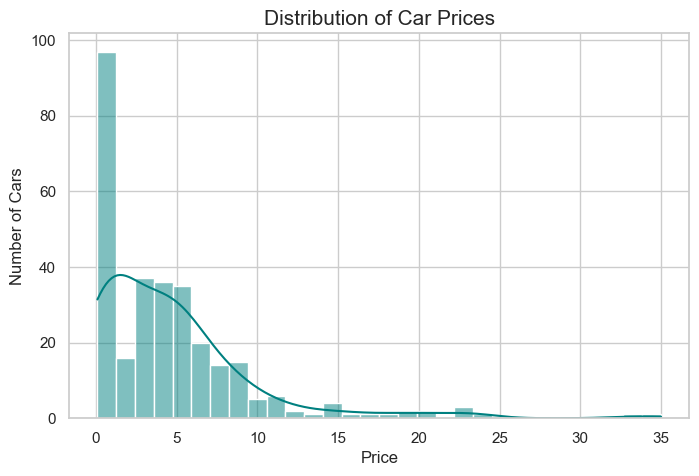

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(auto_df[tgt_col], bins=30, kde=True, color='teal')
plt.title('Distribution of Car Prices', fontsize=15)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)
plt.show()

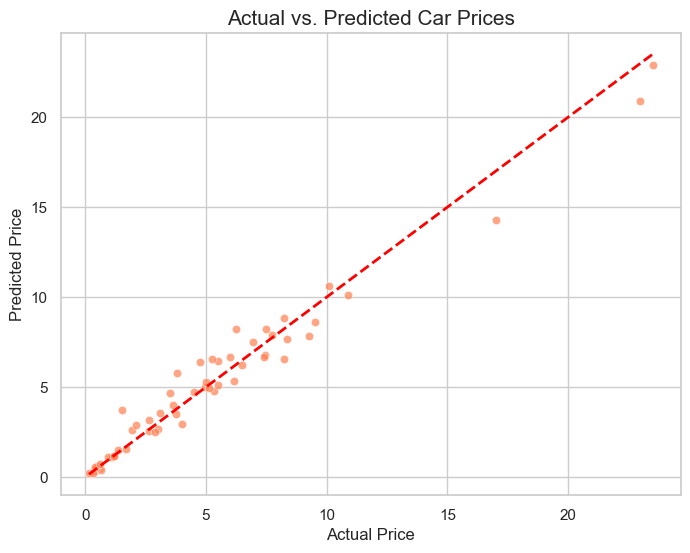

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tst_y, y=est_prices, color='coral', alpha=0.7)

# Draw the line of prediction
max_val = max(tst_y.max(), est_prices.max())
min_val = min(tst_y.min(), est_prices.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title("Actual vs. Predicted Car Prices", fontsize=15)
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.show()

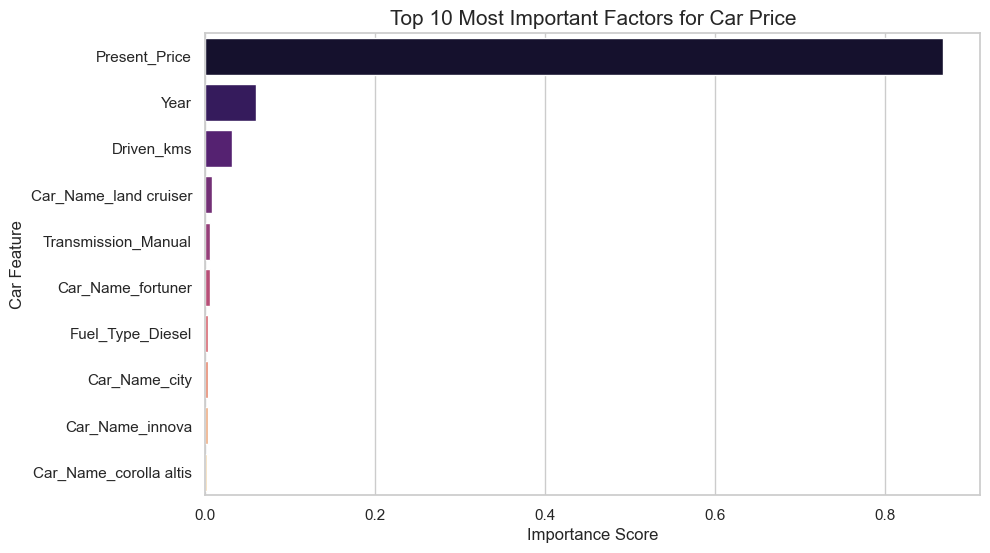

In [15]:
plt.figure(figsize=(10, 6))

# Get feature-importance scores
feat_scores = price_engine.feature_importances_

# Creating mini data-frame for easy sorting
importance_df = pd.DataFrame({
    'Feature': num_inputs.columns,
    'Importance': feat_scores
}).sort_values(by='Importance', ascending=False).head(10) # Grabbing top 10 only

sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)

plt.title("Top 10 Most Important Factors for Car Price", fontsize=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Car Feature", fontsize=12)
plt.show()